# Notebook 3: Classification Experiments

This notebook trains and evaluates classification models to predict GME's daily price direction (up/down) using the sentiment and text features extracted in Notebook 1 and explored in Notebook 2.

**Experimental approach:**
1. Post-level baseline — replicates the reference paper's methodology with a proper time-based split, demonstrating that post-level classification produces near-chance accuracy when data leakage is corrected
2. Feature engineering — PCA dimensionality reduction, correlation-based feature selection, composite features, and sentiment dispersion features
3. Daily-level classification — trains six classifiers across twelve feature sets using 3-fold TimeSeriesSplit cross-validation
4. Comparison against a majority-class baseline (59.1%) to assess practical significance

**Note:** XGBoost is configured with `device="cuda"` and requires a GPU runtime. If running on CPU, remove the `device` parameter from the XGBoost configuration.

## Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import joblib
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

sns.set_style("whitegrid")
RANDOM_STATE = 42
SAVE_DIR = "/content/drive/MyDrive/UC Berkeley/Capstone Project/"

Mounted at /content/drive


In [2]:
df_daily = pd.read_parquet(SAVE_DIR + "dataset2_daily_unweighted.parquet")

df_daily["Date"] = pd.to_datetime(df_daily["Date"])
df_daily = df_daily.sort_values("Date").reset_index(drop=True)
df_daily["target"] = (df_daily["Direction"] == "up").astype(int)

print(f"Daily dataset: {df_daily.shape}")
print(f"Date range: {df_daily['Date'].min().date()} to {df_daily['Date'].max().date()}")
print(f"Direction distribution:\n{df_daily['Direction'].value_counts().to_string()}")

Daily dataset: (44, 103)
Date range: 2021-01-28 to 2021-03-31
Direction distribution:
Direction
down    26
up      18


## Post-Level Baseline

Before working with the daily-aggregated data, we briefly replicate the reference paper's post-level approach using a proper time-based train/test split. The paper used a random stratified split, which allowed posts from the same trading day to appear in both train and test sets. This introduced a form of data leakage that likely inflated the reference paper's accuracy scores.

With a time-based split (train on the first 80% of trading days, test on the last 20%), all models across all feature sets produce accuracies between 47–51%. This is not much better than random guessing on a 53/47 test split. This confirms that post-level classification does not work when leakage is corrected. Detailed results are documented but the experiments are not re-run here due to computational cost (6 hours). All subsequent analysis focuses on the daily-aggregated data.

## Feature Set Definitions

Feature sets are organized by sentiment model, with a shared base of metadata and text features. Only daily mean features are used (standard deviations are reserved for the dispersion experiment).

In [3]:
# Base features (no sentiment)
daily_base = [
    "post_count",
    "score_mean", "comms_num_mean",
    "word_count_mean", "stopword_count_mean", "avg_word_length_mean", "emoji_count_mean",
]

# Sentiment model features
daily_vader = ["vader_pos_mean", "vader_neu_mean", "vader_neg_mean", "vader_compound_mean"]
daily_finbert = ["finbert_pos_mean", "finbert_neu_mean", "finbert_neg_mean"]
daily_roberta = ["roberta_pos_mean", "roberta_neu_mean", "roberta_neg_mean"]
daily_topic = ["topic_strong_pos_mean", "topic_pos_mean", "topic_neu_mean", "topic_neg_mean", "topic_strong_neg_mean"]
daily_goemotions = [c for c in df_daily.columns if c.startswith("emo_") and c.endswith("_mean")]

print("Base feature sets defined:")
for name, feats in [("Base", daily_base), ("VADER", daily_vader), ("FinBERT", daily_finbert),
                     ("RoBERTa", daily_roberta), ("Topic-Sentiment", daily_topic),
                     ("GoEmotions", daily_goemotions)]:
    print(f"  {name}: {len(feats)} features")

Base feature sets defined:
  Base: 7 features
  VADER: 4 features
  FinBERT: 3 features
  RoBERTa: 3 features
  Topic-Sentiment: 5 features
  GoEmotions: 28 features


## PCA Dimensionality Selection

Before applying PCA, we use scree plots to determine the appropriate number of components for each feature group. The 90% cumulative variance threshold is used as a guideline, combined with visual identification of the elbow point.

Based on the scree plots:
- **GoEmotions (28 features):** 12 components (~90% variance)
- **All Sentiment (41 features):** 15 components (~90% variance)
- **Top-10 Correlated (10 features):** 6 components (~90% variance)

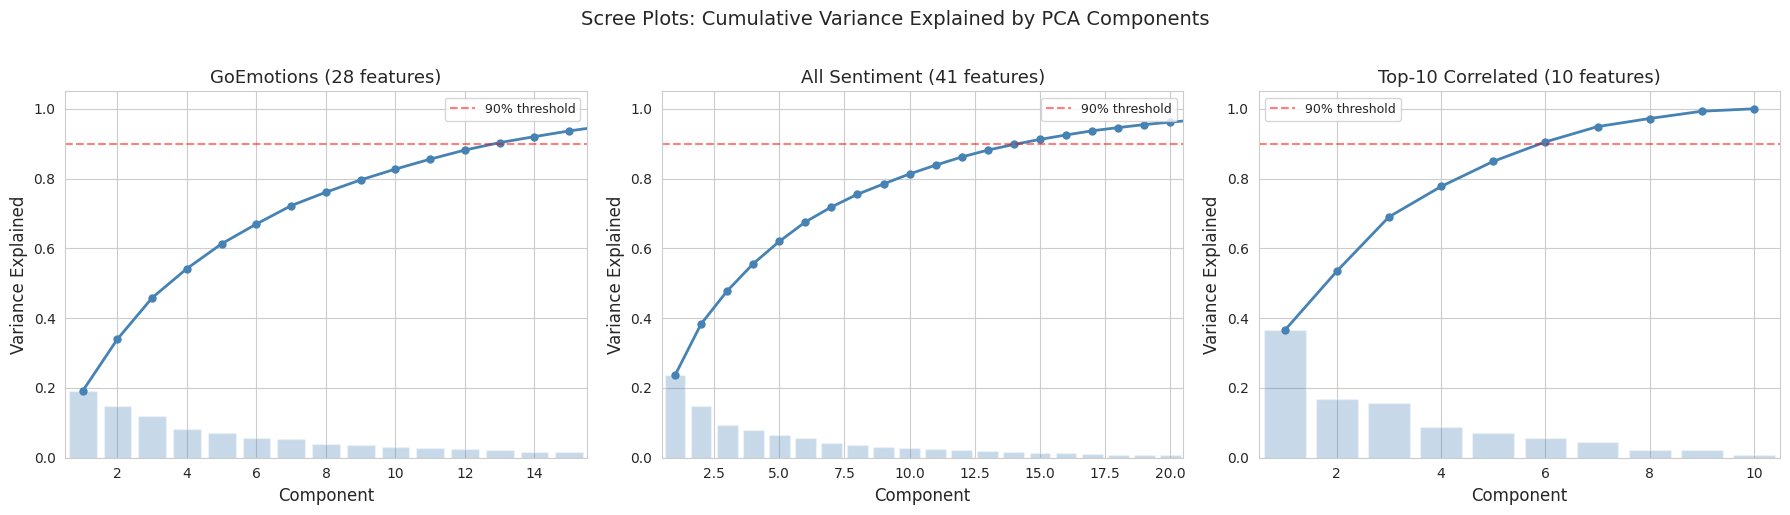


GoEmotions:
  PC1: 0.191 (cumulative: 0.191)
  PC2: 0.149 (cumulative: 0.340)
  PC3: 0.118 (cumulative: 0.458)
  PC4: 0.084 (cumulative: 0.542)
  PC5: 0.071 (cumulative: 0.613)
  PC6: 0.057 (cumulative: 0.670)
  PC7: 0.053 (cumulative: 0.722)
  PC8: 0.039 (cumulative: 0.761)
  PC9: 0.035 (cumulative: 0.796)
  PC10: 0.031 (cumulative: 0.827)
  PC11: 0.028 (cumulative: 0.856)
  PC12: 0.026 (cumulative: 0.882)
  PC13: 0.021 (cumulative: 0.903)
  PC14: 0.017 (cumulative: 0.920)
  PC15: 0.016 (cumulative: 0.937)

All Sentiment:
  PC1: 0.236 (cumulative: 0.236)
  PC2: 0.147 (cumulative: 0.383)
  PC3: 0.095 (cumulative: 0.478)
  PC4: 0.078 (cumulative: 0.556)
  PC5: 0.064 (cumulative: 0.620)
  PC6: 0.056 (cumulative: 0.676)
  PC7: 0.043 (cumulative: 0.719)
  PC8: 0.036 (cumulative: 0.755)
  PC9: 0.030 (cumulative: 0.785)
  PC10: 0.029 (cumulative: 0.813)
  PC11: 0.025 (cumulative: 0.839)
  PC12: 0.023 (cumulative: 0.862)
  PC13: 0.020 (cumulative: 0.882)
  PC14: 0.016 (cumulative: 0.898)
  P

In [4]:
goemotions_cols = [c for c in df_daily.columns if c.startswith("emo_") and c.endswith("_mean")]
all_sentiment_cols = daily_vader + daily_finbert + daily_roberta + daily_topic + goemotions_cols

# Compute correlations for Top-10 feature selection
exclude_from_corr = ["Date", "Direction", "Net_Movement", "target", "post_count"]
corr_candidates = [c for c in df_daily.columns
                   if c not in exclude_from_corr
                   and c.endswith("_mean")
                   and df_daily[c].dtype == "float64"]

correlations = df_daily[corr_candidates].corrwith(df_daily["Net_Movement"]).abs().sort_values(ascending=False)
top_10_features = correlations.head(10).index.tolist()

# Fit full PCA for scree plot visualization
scaler_emo = StandardScaler()
pca_emo_full = PCA(random_state=RANDOM_STATE).fit(scaler_emo.fit_transform(df_daily[goemotions_cols]))

scaler_all = StandardScaler()
pca_all_full = PCA(random_state=RANDOM_STATE).fit(scaler_all.fit_transform(df_daily[all_sentiment_cols]))

scaler_top10 = StandardScaler()
pca_top10_full = PCA(random_state=RANDOM_STATE).fit(scaler_top10.fit_transform(df_daily[top_10_features]))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pca, title, xlim in [
    (axes[0], pca_emo_full, "GoEmotions (28 features)", 15.5),
    (axes[1], pca_all_full, "All Sentiment (41 features)", 20.5),
    (axes[2], pca_top10_full, "Top-10 Correlated (10 features)", 10.5),
]:
    n = len(pca.explained_variance_ratio_)
    ax.bar(range(1, n + 1), pca.explained_variance_ratio_, color="steelblue", alpha=0.3)
    ax.plot(range(1, n + 1), np.cumsum(pca.explained_variance_ratio_),
            marker="o", markersize=5, color="steelblue", linewidth=2)
    ax.axhline(y=0.90, color="red", linestyle="--", alpha=0.5, label="90% threshold")
    ax.set_xlabel("Component", fontsize=12)
    ax.set_ylabel("Variance Explained", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.set_xlim(0.5, xlim)

plt.suptitle("Scree Plots: Cumulative Variance Explained by PCA Components", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Print cumulative variance for reference
for name, pca in [("GoEmotions", pca_emo_full), ("All Sentiment", pca_all_full), ("Top-10 Corr", pca_top10_full)]:
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    print(f"\n{name}:")
    for i in range(min(15, len(cumvar))):
        print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:.3f} (cumulative: {cumvar[i]:.3f})")

## Feature Engineering

Several feature engineering techniques are applied to test whether transformed or combined features improve classification performance:

1. **Composite features** — hand-engineered features based on EDA findings (polarization scores, bullish ratios, solidarity/cognitive indices, log transforms)
2. **Correlation-based selection** — top 5 and top 10 features by absolute correlation with Net_Movement
3. **Sentiment dispersion** — standard deviations of the top-correlated features, capturing within-day agreement
4. **PCA compression** — dimensionality reduction for GoEmotions (28→12), all sentiment (41→15), and top-10 correlated features (10→6), with component counts determined by scree plot analysis
5. **Hybrid PCA** — PCA applied to the top-10 correlated features

In [5]:
# 1. Composite features
df_daily["log_post_count"] = np.log1p(df_daily["post_count"])
df_daily["log_score_mean"] = np.log1p(df_daily["score_mean"])

df_daily["vader_polarization"] = 1 - df_daily["vader_neu_mean"]
df_daily["finbert_polarization"] = 1 - df_daily["finbert_neu_mean"]
df_daily["roberta_polarization"] = 1 - df_daily["roberta_neu_mean"]
df_daily["topic_polarization"] = 1 - df_daily["topic_neu_mean"]

df_daily["vader_bullish_ratio"] = df_daily["vader_pos_mean"] / (df_daily["vader_pos_mean"] + df_daily["vader_neg_mean"]).clip(lower=1e-8)
df_daily["finbert_bullish_ratio"] = df_daily["finbert_pos_mean"] / (df_daily["finbert_pos_mean"] + df_daily["finbert_neg_mean"]).clip(lower=1e-8)
df_daily["roberta_bullish_ratio"] = df_daily["roberta_pos_mean"] / (df_daily["roberta_pos_mean"] + df_daily["roberta_neg_mean"]).clip(lower=1e-8)
df_daily["topic_bullish_ratio"] = df_daily["topic_pos_mean"] / (df_daily["topic_pos_mean"] + df_daily["topic_neg_mean"]).clip(lower=1e-8)

df_daily["solidarity_index"] = df_daily["emo_love_mean"] + df_daily["emo_gratitude_mean"] + df_daily["emo_approval_mean"]
df_daily["cognitive_index"] = df_daily["emo_realization_mean"] + df_daily["emo_surprise_mean"] + df_daily["emo_confusion_mean"]

composite_features = [
    "log_post_count", "log_score_mean",
    "vader_polarization", "finbert_polarization", "roberta_polarization", "topic_polarization",
    "vader_bullish_ratio", "finbert_bullish_ratio", "roberta_bullish_ratio", "topic_bullish_ratio",
    "solidarity_index", "cognitive_index",
]
print(f"Composite features created: {len(composite_features)}")

# 2. Correlation-based feature selection
exclude_from_corr = ["Date", "Direction", "Net_Movement", "target", "post_count",
                     "log_post_count", "log_score_mean"] + composite_features
corr_candidates = [c for c in df_daily.columns
                   if c not in exclude_from_corr and c.endswith("_mean") and df_daily[c].dtype == "float64"]

correlations = df_daily[corr_candidates].corrwith(df_daily["Net_Movement"]).abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()
top_10_features = correlations.head(10).index.tolist()

print(f"\nTop 5 correlated features: {top_5_features}")
print(f"Top 10 correlated features: {top_10_features}")

# 3. Sentiment dispersion
top_5_std = [f.replace("_mean", "_std") for f in top_5_features if f.replace("_mean", "_std") in df_daily.columns]
dispersion_features = top_5_features + top_5_std
print(f"\nDispersion features: {len(dispersion_features)}")

# 4. PCA: GoEmotions (12 components)
scaler_emo = StandardScaler()
emo_scaled = scaler_emo.fit_transform(df_daily[goemotions_cols])
pca_emo = PCA(n_components=12, random_state=RANDOM_STATE)
for i, col in enumerate(pca_emo.fit_transform(emo_scaled).T):
    df_daily[f"emo_pca_{i+1}"] = col
print(f"\nGoEmotions PCA-12: {sum(pca_emo.explained_variance_ratio_)*100:.1f}% variance explained")
goemotions_pca_features = [f"emo_pca_{i+1}" for i in range(12)]

# 5. PCA: All Sentiment (15 components)
scaler_all = StandardScaler()
all_scaled = scaler_all.fit_transform(df_daily[all_sentiment_cols])
pca_all = PCA(n_components=15, random_state=RANDOM_STATE)
for i, col in enumerate(pca_all.fit_transform(all_scaled).T):
    df_daily[f"all_sent_pca_{i+1}"] = col
print(f"All Sentiment PCA-15: {sum(pca_all.explained_variance_ratio_)*100:.1f}% variance explained")
all_sent_pca_features = [f"all_sent_pca_{i+1}" for i in range(15)]

# 6. PCA: Top-10 hybrid (6 components)
scaler_top10 = StandardScaler()
top10_scaled = scaler_top10.fit_transform(df_daily[top_10_features])
pca_top10 = PCA(n_components=6, random_state=RANDOM_STATE)
for i, col in enumerate(pca_top10.fit_transform(top10_scaled).T):
    df_daily[f"top10_pca_{i+1}"] = col
print(f"Top-10 PCA-6: {sum(pca_top10.explained_variance_ratio_)*100:.1f}% variance explained")
top10_pca_features = [f"top10_pca_{i+1}" for i in range(6)]

Composite features created: 12

Top 5 correlated features: ['finbert_neu_mean', 'vader_pos_mean', 'vader_neu_mean', 'emo_approval_mean', 'avg_word_length_mean']
Top 10 correlated features: ['finbert_neu_mean', 'vader_pos_mean', 'vader_neu_mean', 'emo_approval_mean', 'avg_word_length_mean', 'finbert_pos_mean', 'topic_strong_pos_mean', 'emo_realization_mean', 'emo_surprise_mean', 'emo_anger_mean']

Dispersion features: 10

GoEmotions PCA-12: 88.2% variance explained
All Sentiment PCA-15: 91.2% variance explained
Top-10 PCA-6: 90.5% variance explained


## Engineered Feature Sets

Twelve feature sets are defined for the classification experiments. Raw GoEmotions (35 features) and All Models (50 features) are excluded due to the high feature-to-observation ratio (n=44). They are replaced by their PCA-compressed versions.

In [6]:
engineered_feature_sets = {
    "Base Only": daily_base,
    "VADER": daily_base + daily_vader,
    "FinBERT": daily_base + daily_finbert,
    "RoBERTa": daily_base + daily_roberta,
    "Topic-Sentiment": daily_base + daily_topic,
    "Top-5 Corr": top_5_features,
    "Top-10 Corr": top_10_features,
    "GoEmotions PCA-12": daily_base + goemotions_pca_features,
    "All Sent PCA-15": daily_base + all_sent_pca_features,
    "Composite": daily_base + composite_features,
    "Best + Dispersion": daily_base + dispersion_features,
    "Top-10 + PCA-6": top10_pca_features,
}

print("Engineered Feature Sets:")
print("-" * 40)
for name, features in engineered_feature_sets.items():
    print(f"  {name}: {len(features)} features")
print(f"\nTotal feature sets: {len(engineered_feature_sets)}")
print(f"Total experiments (x6 classifiers): {len(engineered_feature_sets) * 6}")

Engineered Feature Sets:
----------------------------------------
  Base Only: 7 features
  VADER: 11 features
  FinBERT: 10 features
  RoBERTa: 10 features
  Topic-Sentiment: 12 features
  Top-5 Corr: 5 features
  Top-10 Corr: 10 features
  GoEmotions PCA-12: 19 features
  All Sent PCA-15: 22 features
  Composite: 19 features
  Best + Dispersion: 17 features
  Top-10 + PCA-6: 6 features

Total feature sets: 12
Total experiments (x6 classifiers): 72


## Classification Experiments

Six classifiers are trained on each feature set using 3-fold TimeSeriesSplit cross-validation with GridSearchCV for hyperparameter tuning. All classifiers are wrapped in a StandardScaler pipeline for consistency.

**Overfitting countermeasures for n=44:**
- Strong regularization parameters (low C values for linear models, high alpha for MLP)
- Tree depth capped at reasonable levels with minimum leaf size constraints
- L1/L2 regularization on XGBoost
- Small hidden layer sizes for MLP

The majority-class baseline (always predicting "down") achieves 59.1% accuracy. Models are flagged with `[+]` if they exceed this baseline.

In [7]:
CV = TimeSeriesSplit(n_splits=3)
MAJORITY_BASELINE = df_daily["target"].value_counts(normalize=True).max()

print(f"Majority class baseline accuracy: {MAJORITY_BASELINE:.3f}")
print(f"Cross-validation: 3-fold TimeSeriesSplit")

classifiers = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=RANDOM_STATE, max_iter=5000),
        "params": {
            "clf__C": [0.001, 0.01, 0.1, 1, 10],
            "clf__penalty": ["l1", "l2"],
            "clf__solver": ["saga"],
        }
    },
    "SVM": {
        "model": SVC(random_state=RANDOM_STATE),
        "params": {
            "clf__C": [0.001, 0.01, 0.1, 1, 10],
            "clf__kernel": ["linear", "rbf"],
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "params": {
            "clf__max_depth": [3, 5, 7, None],
            "clf__min_samples_split": [2, 3, 5],
            "clf__min_samples_leaf": [1, 2, 3],
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__max_depth": [3, 5, 7, None],
            "clf__min_samples_split": [2, 3, 5],
            "clf__min_samples_leaf": [1, 2, 3],
        }
    },
    "MLP": {
        "model": MLPClassifier(random_state=RANDOM_STATE, max_iter=2000),
        "params": {
            "clf__hidden_layer_sizes": [(8,), (16,), (8, 4)],
            "clf__alpha": [0.01, 0.1, 1.0],
        }
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", device="cuda"),
        "params": {
            "clf__n_estimators": [25, 50, 100],
            "clf__max_depth": [2, 3],
            "clf__learning_rate": [0.01, 0.1],
            "clf__reg_alpha": [0, 0.1, 1.0],
            "clf__reg_lambda": [1.0, 5.0],
        }
    },
}

Majority class baseline accuracy: 0.591
Cross-validation: 3-fold TimeSeriesSplit


In [8]:
def train_and_evaluate(X, y, classifiers, cv, dataset_name):
    """Run GridSearchCV for each classifier and return results and fitted models."""
    results = []
    fitted_models = {}

    for clf_name, clf_config in classifiers.items():
        print(f"    {clf_name}...", end=" ", flush=True)

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", clf_config["model"]),
        ])

        grid = GridSearchCV(
            pipe, clf_config["params"],
            cv=cv, scoring="accuracy", n_jobs=-1, refit=True,
        )
        grid.fit(X, y)

        best_idx = grid.best_index_
        fold_scores = [grid.cv_results_[f"split{i}_test_score"][best_idx] for i in range(cv.n_splits)]

        result = {
            "Feature Set": dataset_name,
            "Classifier": clf_name,
            "Features": X.shape[1],
            "CV Accuracy": grid.best_score_,
            "Fold 1": fold_scores[0],
            "Fold 2": fold_scores[1],
            "Fold 3": fold_scores[2],
            "Std": np.std(fold_scores),
            "vs Baseline": grid.best_score_ - MAJORITY_BASELINE,
        }

        marker = "+" if result["vs Baseline"] > 0 else " "
        print(f"CV Acc: {grid.best_score_:.3f} [{marker}]")

        results.append(result)
        fitted_models[clf_name] = grid.best_estimator_

    return pd.DataFrame(results), fitted_models

In [9]:
print("=" * 70)
print("DAILY UNWEIGHTED — ENGINEERED FEATURE SETS")
print("=" * 70)

all_results = []
all_models = {}

for feat_name, feat_cols in engineered_feature_sets.items():
    print(f"\n  Feature set: {feat_name} ({len(feat_cols)} features)")

    X = df_daily[feat_cols]
    y = df_daily["target"]

    result_df, models = train_and_evaluate(X, y, classifiers, CV, feat_name)
    all_results.append(result_df)
    all_models[feat_name] = models

all_results = pd.concat(all_results, ignore_index=True)

# Save results and models
all_results.to_csv(SAVE_DIR + "engineered_results.csv", index=False)
joblib.dump(all_models, SAVE_DIR + "engineered_models.joblib")
print(f"\nTotal experiments: {len(all_results)}")
print("Results and models saved.")

DAILY UNWEIGHTED — ENGINEERED FEATURE SETS

  Feature set: Base Only (7 features)
    Logistic Regression... CV Acc: 0.667 [+]
    SVM... CV Acc: 0.667 [+]
    Decision Tree... CV Acc: 0.455 [ ]
    Random Forest... CV Acc: 0.545 [ ]
    MLP... CV Acc: 0.606 [+]
    XGBoost... CV Acc: 0.545 [ ]

  Feature set: VADER (11 features)
    Logistic Regression... CV Acc: 0.636 [+]
    SVM... CV Acc: 0.576 [ ]
    Decision Tree... CV Acc: 0.606 [+]
    Random Forest... CV Acc: 0.485 [ ]
    MLP... CV Acc: 0.667 [+]
    XGBoost... CV Acc: 0.545 [ ]

  Feature set: FinBERT (10 features)
    Logistic Regression... CV Acc: 0.636 [+]
    SVM... CV Acc: 0.606 [+]
    Decision Tree... CV Acc: 0.485 [ ]
    Random Forest... CV Acc: 0.576 [ ]
    MLP... CV Acc: 0.606 [+]
    XGBoost... CV Acc: 0.545 [ ]

  Feature set: RoBERTa (10 features)
    Logistic Regression... CV Acc: 0.606 [+]
    SVM... CV Acc: 0.576 [ ]
    Decision Tree... CV Acc: 0.455 [ ]
    Random Forest... CV Acc: 0.485 [ ]
    MLP... C

## Results

Three views of the results are presented:
1. **Best classifier per feature set** — which algorithm works best for each set of features
2. **Best feature set per classifier** — which features each algorithm prefers
3. **Full pivot table** — complete accuracy matrix for all 72 experiments

In [10]:
# Best classifier per feature set
best_per_feature = (
    all_results
    .sort_values("CV Accuracy", ascending=False)
    .groupby("Feature Set", sort=False)
    .first()
    .reset_index()
    [["Feature Set", "Classifier", "Features", "CV Accuracy", "Std", "vs Baseline"]]
    .sort_values("CV Accuracy", ascending=False)
    .style
    .format({"CV Accuracy": "{:.3f}", "Std": "{:.3f}", "vs Baseline": "{:+.3f}"})
    .background_gradient(subset=["CV Accuracy"], cmap="RdYlGn", vmin=0.4, vmax=0.75)
    .background_gradient(subset=["vs Baseline"], cmap="RdYlGn", vmin=-0.15, vmax=0.15)
    .set_caption("Best Classifier per Feature Set")
)
display(best_per_feature)

,Feature Set,Classifier,Features,CV Accuracy,Std,vs Baseline
0,Best + Dispersion,SVM,17,0.697,0.187,+0.106
1,Base Only,Logistic Regression,7,0.667,0.113,+0.076
2,VADER,MLP,11,0.667,0.281,+0.076
3,FinBERT,Logistic Regression,10,0.636,0.257,+0.045
4,Composite,SVM,19,0.636,0.223,+0.045
5,Top-10 + PCA-6,SVM,6,0.636,0.268,+0.045
6,Top-5 Corr,Decision Tree,5,0.606,0.214,+0.015
7,Top-10 Corr,Logistic Regression,10,0.606,0.239,+0.015
8,RoBERTa,Logistic Regression,10,0.606,0.155,+0.015
9,Topic-Sentiment,Logistic Regression,12,0.606,0.155,+0.015


In [11]:
# Best feature set per classifier
best_per_clf = (
    all_results
    .sort_values("CV Accuracy", ascending=False)
    .groupby("Classifier", sort=False)
    .first()
    .reset_index()
    [["Classifier", "Feature Set", "Features", "CV Accuracy", "Std", "vs Baseline"]]
    .sort_values("CV Accuracy", ascending=False)
    .style
    .format({"CV Accuracy": "{:.3f}", "Std": "{:.3f}", "vs Baseline": "{:+.3f}"})
    .background_gradient(subset=["CV Accuracy"], cmap="RdYlGn", vmin=0.4, vmax=0.75)
    .background_gradient(subset=["vs Baseline"], cmap="RdYlGn", vmin=-0.15, vmax=0.15)
    .set_caption("Best Feature Set per Classifier")
)
display(best_per_clf)

,Classifier,Feature Set,Features,CV Accuracy,Std,vs Baseline
0,SVM,Best + Dispersion,17,0.697,0.187,+0.106
1,Logistic Regression,Base Only,7,0.667,0.113,+0.076
2,MLP,VADER,11,0.667,0.281,+0.076
3,Decision Tree,Top-10 + PCA-6,6,0.606,0.239,+0.015
4,XGBoost,Best + Dispersion,17,0.606,0.239,+0.015
5,Random Forest,Top-10 Corr,10,0.606,0.239,+0.015


In [12]:
# Full pivot table
pivot = all_results.pivot(index="Feature Set", columns="Classifier", values="CV Accuracy")
pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]

pivot_styled = (
    pivot
    .style
    .format("{:.3f}")
    .background_gradient(cmap="RdYlGn", vmin=0.4, vmax=0.75)
    .set_caption(f"CV Accuracy: Feature Set x Classifier (Baseline: {MAJORITY_BASELINE:.3f})")
)
display(pivot_styled)

Classifier,Decision Tree,Logistic Regression,MLP,Random Forest,SVM,XGBoost
Feature Set,,,,,,
Best + Dispersion,0.515,0.636,0.636,0.576,0.697,0.606
Base Only,0.455,0.667,0.606,0.545,0.667,0.545
VADER,0.606,0.636,0.667,0.485,0.576,0.545
Composite,0.485,0.606,0.606,0.576,0.636,0.545
Top-10 + PCA-6,0.606,0.606,0.606,0.545,0.636,0.545
FinBERT,0.485,0.636,0.606,0.576,0.606,0.545
Top-5 Corr,0.606,0.576,0.545,0.545,0.545,0.545
RoBERTa,0.455,0.606,0.515,0.485,0.576,0.545
Topic-Sentiment,0.545,0.606,0.485,0.485,0.576,0.545


## Analysis

**Top results:**
- SVM + Best + Dispersion: 69.7% (std 0.187) — highest accuracy but moderate variance
- Logistic Regression + Base Only: 66.7% (std 0.113) — most stable result
- MLP + VADER: 66.7% (std 0.281) — high variance undermines confidence

**Key findings:**

**Base features are surprisingly competitive.** Logistic Regression with just 7 metadata and text features (post count, engagement, word structure) ties or beats most sentiment-enhanced models at 66.7%. Adding sentiment does not consistently improve predictions.

**No sentiment model clearly dominates.** VADER, FinBERT, RoBERTa, Topic-Sentiment, and GoEmotions all produce similar accuracy ranges. Despite theoretical advantages of domain-adapted transformers, none translates to meaningfully better price prediction on this dataset.

**More features degrade performance.** PCA-compressed feature sets (GoEmotions PCA-12, All Sent PCA-15) underperform simpler feature sets. The raw GoEmotions and All Models sets were excluded entirely due to dimensionality concerns (50 features on 44 rows).

**Feature engineering provided marginal improvement.** The Best + Dispersion set (top-correlated features plus their standard deviations) produced the highest accuracy, but the improvement over Base Only is within the noise range given the fold variance.

**Linear models outperform complex ones.** Logistic Regression and SVM are the most consistently strong classifiers. Decision Tree, Random Forest, and XGBoost generally underperform, likely because regularization constraints necessary for n=44 limit their ability to capture nonlinear patterns.

**Overall conclusion:** Reddit sentiment from r/wallstreetbets does not reliably predict GME daily price direction. With properly constructed datasets that avoid data leakage, no combination of sentiment model, feature engineering, and classifier consistently beats the majority-class baseline by a meaningful margin. This contradicts the reference paper's 99% accuracy and demonstrates that their result was an artifact of methodological flaws.